In [1]:
import torch
import numpy as np
import pandas as pd 
from torch.utils.data import Dataset
from torchvision import datasets, transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
import os
from skimage import io
import torch.nn as nn
from torch.optim import Adam
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.metrics import roc_auc_score

In [ ]:
size = 128
INPUT_DIM = 3 * size * size
HIDDEN_DIM = 4096        
LATENT_DIM = 512
device = "cuda" if torch.cuda.is_available() else "cpu"
lr = 1e-3
epochs = 10
batch_size = 32

In [3]:
transform = transforms.Compose([
    transforms.Resize((size, size)),
    transforms.ToTensor(),
])

train_set = datasets.ImageFolder(root='data/train', transform=transform)
test_set = datasets.ImageFolder(root='data/test', transform=transform)
gt_set = datasets.ImageFolder(root='data/ground_truth', transform=transform)

In [4]:
print(train_set)

Dataset ImageFolder
    Number of datapoints: 280
    Root location: data/train
    StandardTransform
Transform: Compose(
               Resize(size=(128, 128), interpolation=bilinear, max_size=None, antialias=True)
               ToTensor()
           )


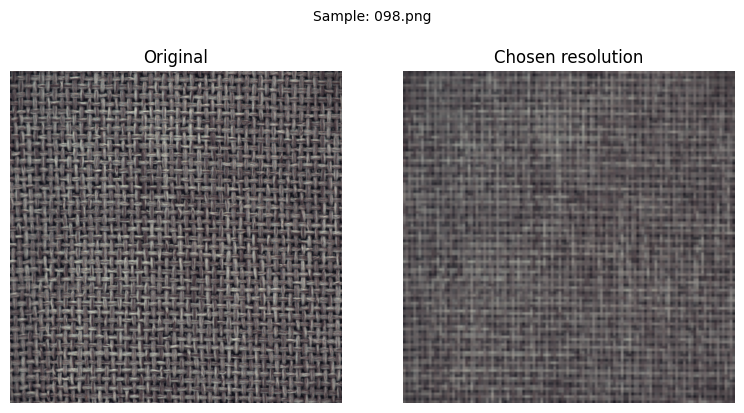

In [5]:

# Pick one sample image from the train folder
sample_class = os.listdir('data/train')[0]
sample_file  = os.listdir(f'data/train/{sample_class}')[0]
sample_path  = f'data/train/{sample_class}/{sample_file}'

# Original image
img_original = Image.open(sample_path).convert('RGB')

# Resized image (chosen resolution)
img_resized = transforms.Resize((size, size))(img_original)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))

axes[0].imshow(img_original)
axes[0].set_title(f'Original')
axes[0].axis('off')

axes[1].imshow(img_resized)
axes[1].set_title(f'Chosen resolution')
axes[1].axis('off')

plt.suptitle(f'Sample: {sample_file}', fontsize=10, y=1.02)
plt.tight_layout()
plt.show()


In [6]:
train_loader = DataLoader(dataset=train_set, batch_size=32, shuffle=True)
test_loader = DataLoader(dataset=test_set, batch_size=32, shuffle=True)
gt_loader = DataLoader(dataset=gt_set, batch_size=32, shuffle=True)

In [7]:
class Encoder(nn.Module):
    def __init__(self, input_dim, hidden_dim, latent_dim):
        super().__init__()
        
        self.encoder_body = nn.Sequential(
            nn.Linear(input_dim, hidden_dim * 2),
            nn.BatchNorm1d(hidden_dim * 2),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3), 
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.LeakyReLU(0.2)
        )

        self.mu_head = nn.Linear(hidden_dim, latent_dim)
        self.logvar_head = nn.Linear(hidden_dim, latent_dim)

    def forward(self, x):
        h = self.encoder_body(x)
        mu = self.mu_head(h)
        logvar = self.logvar_head(h)
        return mu, logvar

    def reparametrize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + (eps * std)

class Decoder(nn.Module):
    def __init__(self, latent_dim, hidden_dim, output_dim):
        super().__init__()
        
        self.decoder_body = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim, hidden_dim * 2),
            nn.BatchNorm1d(hidden_dim * 2),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.Linear(hidden_dim * 2, output_dim)
        )

    def forward(self, z):
        h = self.decoder_body(z)
        x_hat = torch.sigmoid(h) 
        return x_hat

class VAE(nn.Module):
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def forward(self, x):
        mu, logvar = self.encoder(x)
        z = self.encoder.reparametrize(mu, logvar)
        x_hat = self.decoder(z)
        return x_hat, mu, logvar

In [8]:
"""class Encoder(nn.Module):
    def __init__(self, input_dim, hidden_dim, latent_dim):
        super().__init__()
        self.fc_input = nn.Linear(input_dim, hidden_dim)
        self.relu = nn.ReLU()

        self.mu_head = nn.Linear(hidden_dim, latent_dim)
        self.logvar_head = nn.Linear(hidden_dim, latent_dim)

    def forward(self, x):
        h = self.relu(self.fc_input(x))
        mu = self.mu_head(h)
        logvar = self.logvar_head(h)
        return mu, logvar

    def reparametrize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + (eps * std)

class Decoder(nn.Module):
    def __init__(self, latent_dim, hidden_dim, output_dim):
        super().__init__()
        self.fc_input = nn.Linear(latent_dim, hidden_dim)
        self.fc_hidden = nn.Linear(hidden_dim, hidden_dim)
        self.fc_output = nn.Linear(hidden_dim, output_dim)
        self.relu = nn.ReLU()

    def forward(self, x):
        h1 = self.relu(self.fc_input(x))
        h2 = self.relu(self.fc_hidden(h1))
        x_hat = torch.sigmoid(self.fc_output(h2)) 
        return x_hat

class VAE(nn.Module):
    def __init__(self, encoder, decoder):
        super().__init__() 
        self.encoder = encoder
        self.decoder = decoder

    def forward(self, x):
        mu, logvar = self.encoder(x)
        z = self.encoder.reparametrize(mu, logvar)
        x_hat = self.decoder(z)
        return x_hat, mu, logvar"""

'class Encoder(nn.Module):\n    def __init__(self, input_dim, hidden_dim, latent_dim):\n        super().__init__()\n        self.fc_input = nn.Linear(input_dim, hidden_dim)\n        self.relu = nn.ReLU()\n\n        self.mu_head = nn.Linear(hidden_dim, latent_dim)\n        self.logvar_head = nn.Linear(hidden_dim, latent_dim)\n\n    def forward(self, x):\n        h = self.relu(self.fc_input(x))\n        mu = self.mu_head(h)\n        logvar = self.logvar_head(h)\n        return mu, logvar\n\n    def reparametrize(self, mu, logvar):\n        std = torch.exp(0.5 * logvar)\n        eps = torch.randn_like(std)\n        return mu + (eps * std)\n\nclass Decoder(nn.Module):\n    def __init__(self, latent_dim, hidden_dim, output_dim):\n        super().__init__()\n        self.fc_input = nn.Linear(latent_dim, hidden_dim)\n        self.fc_hidden = nn.Linear(hidden_dim, hidden_dim)\n        self.fc_output = nn.Linear(hidden_dim, output_dim)\n        self.relu = nn.ReLU()\n\n    def forward(self, x):

In [9]:
encoder = Encoder(input_dim=INPUT_DIM, hidden_dim=HIDDEN_DIM, latent_dim=LATENT_DIM)
decoder = Decoder(latent_dim=LATENT_DIM, hidden_dim=HIDDEN_DIM, output_dim=INPUT_DIM)
model_vae = VAE(encoder=encoder, decoder=decoder).to(device)

In [10]:
def loss_function(x, x_hat, mean, log_var):
    reproduction_loss = nn.functional.binary_cross_entropy(x_hat, x, reduction='sum')
    kld = - 0.5 * torch.sum(1+ log_var - mean.pow(2) - log_var.exp())

    return reproduction_loss + kld

optimizer = Adam(model_vae.parameters(), lr=lr)

In [11]:
print("Start training VAE...")
model_vae.train()

for epoch in range(epochs):
    overall_loss = 0
    for batch_idx, (x, _) in enumerate(train_loader):
        x = torch.flatten(x, start_dim=1)
        x = x.to(device)
        optimizer.zero_grad()
        x_hat, mu, logvar = model_vae(x)
        loss = loss_function(x, x_hat, mu, logvar)
        overall_loss += loss.item()
        loss.backward()
        optimizer.step()

        num_batches = batch_idx + 1
    print(f"\tEpoch {epoch+1} complete!\tAverage Loss: {overall_loss / (num_batches * batch_size * size**2):.4f}")

print("FINISHED!")




Start training VAE...
	Epoch 1 complete!	Average Loss: 24521.8294
	Epoch 2 complete!	Average Loss: 156.7362
	Epoch 3 complete!	Average Loss: 39.5446
	Epoch 4 complete!	Average Loss: 87.9301
	Epoch 5 complete!	Average Loss: 12397.6067
	Epoch 6 complete!	Average Loss: 7.0201
	Epoch 7 complete!	Average Loss: 6277.1845
	Epoch 8 complete!	Average Loss: 15.3312
	Epoch 9 complete!	Average Loss: 12.8892
	Epoch 10 complete!	Average Loss: 5.1115
FINISHED!


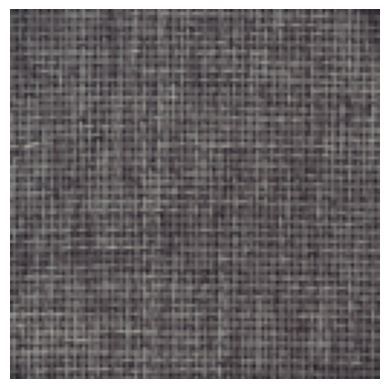

In [12]:
model_vae.eval()
with torch.no_grad():
    for batch_idx, (x, _) in enumerate(train_loader):
        x = torch.flatten(x, start_dim=1).to(device) 
        x_hat, _, _ = model_vae(x)
        break

def show_image(x, idx):
    img = x[idx].view(3, *(size, size))       
    img = img.cpu().permute(1, 2, 0).numpy() 
    plt.figure()
    plt.imshow(img)
    plt.axis('off')
    plt.show()
show_image(x, idx=0)

In [ ]:

image_recon_errors = []
image_labels = []
pixel_recon_errors = []
pixel_masks = []
print("Evaluating test set...")
model_vae.eval()
with torch.no_grad():
    for x, label in test_loader:
        
        x_flat = torch.flatten(x, start_dim=1).to(device)
        x_hat_flat, _, _ = model_vae(x_flat)
        
        x = x.to(device)
        x_hat = x_hat_flat.view_as(x)
        error_map = torch.mean((x - x_hat) ** 2, dim=1)
        image_error = error_map.mean(dim=[1, 2]).cpu().numpy()
        image_recon_errors.extend(image_error)
        image_labels.extend(label.numpy())
        
        pixel_recon_errors.extend(error_map.cpu().numpy().flatten())
binary_labels = [0 if l == 2 else 1 for l in image_labels]
image_auroc = roc_auc_score(binary_labels, image_recon_errors)
print(f"Image-Level AUROC: {image_auroc:.4f}")

Evaluating test set...
Image-Level AUROC: 0.5602


In [14]:
import gc
gc.collect()
torch.cuda.empty_cache()